    In this notebook we will use the functions already discussed in earlier notebooks and construct the hamiltonian for BdG calculations.
    While these functions already exists in the modules, we include it here to understand it

In [8]:
using LinearAlgebra
using CSV
using DataFrames
using Plots
using DelimitedFiles

In [2]:
# Importing personal modules
include("src/bdg_utilities.jl")
include("src/general_utils.jl")

Main.GeneralUtils

In [3]:
# Loading personal modules
using .BdGUtilities: generate_t_map, extract_geometry, build_H_twisted, generate_t_matrix
using .GeneralUtils: fermi_fn, show_all, show_matrix

f = fermi_fn

fermi_fn (generic function with 2 methods)

In [4]:
function build_h_spinful(H0, mu, nSites;
                         impuritySite=0, J=0.0, K=0.0,
                         x=nothing, y=nothing, neighbors=nothing,
                         lambda=0.0, tMap=nothing)

    T = eltype(H0)
    h = zeros(ComplexF64, 2nSites, 2nSites)

    for i in 1:nSites
        # onsite shifts
        onsite_up = -mu
        onsite_dn = -mu
        if i == impuritySite
            onsite_up += -(K - (+1)*J)
            onsite_dn += -(K - (-1)*J)
        end

        h[i,i]         += onsite_up
        h[nSites+i, nSites+i] += onsite_dn
    end

    # add hopping (spin-conserving)
    for i in 1:nSites, j in 1:nSites
        hij = H0[i,j]
        if hij != 0
            h[i,j]               += hij
            h[nSites+i, nSites+j] += hij
        end
    end

    # add Rashba SOC (spin-flip) into h
    if lambda != 0.0
        @assert x !== nothing && y !== nothing && neighbors !== nothing
        for i in 1:nSites
            xi, yi = x[i], y[i]
            for j in neighbors[i]
                if j > i  # avoid double counting;
                    dx = x[j] - xi
                    dy = y[j] - yi

                    tij = tMap === nothing ? 1.0 :
                          get(tMap, (i,j), get(tMap, (j,i), 1.0))

                    S_ij = -im * lambda * tij * (-dy - im*dx)

                    S_ji = -im * lambda * tij * (-( -dy) - im*(-dx))

                    # spin-flip blocks: up->down and down->up
                    # indices: up_i = i, down_i = N+i
                    h[i,        nSites + j] += S_ij
                    h[j,        nSites + i] += S_ji

                    # Hermitian conjugates (down->up)
                    h[nSites + j, i       ] += conj(S_ij)
                    h[nSites + i, j       ] += conj(S_ji)
                end
            end
        end
    end

    return h
end


# singlet pairing matrix Δ (2N x 2N) in spin space
function build_Delta_singlet(deltaList, nSites)
    Δ = zeros(ComplexF64, 2nSites, 2nSites)
    for i in 1:nSites
        Δ[i,        nSites+i] += deltaList[i]
        Δ[nSites+i, i       ] += -deltaList[i]
    end
    return Δ
end


# ------------------------------------------------------------
# BdG (4N x 4N) in basis:
# (c_up, c_dn, c_up†, c_dn†)
# BdG = [ h    Δ
#         Δ†  -h^T ]
# ------------------------------------------------------------
function build_BdG_canonical(h, Δ)
    n2 = size(h,1)
    @assert size(h,2) == n2
    @assert size(Δ) == (n2,n2)

    HBdG = zeros(ComplexF64, 2n2, 2n2)
    HBdG[1:n2,     1:n2]     .= h
    HBdG[1:n2,     n2+1:end] .= Δ
    HBdG[n2+1:end, 1:n2]     .= adjoint(Δ)
    HBdG[n2+1:end, n2+1:end] .= -transpose(h)

    return HBdG
end


# ------------------------------------------------------------
# BdG into present basis: (from Ptok's Paper)
# basis blocks (each length N):
#   1: c_up
#   2: c_dn†
#   3: c_dn
#   4: c_up†
#
# Usual/Standard BdG basis blocks:
#   1: c_up
#   2: c_dn
#   3: c_up†
#   4: c_dn†
#
# Mapping (Present Basis <- Standard):
#   user1 = can1
#   user2 = can4
#   user3 = can2
#   user4 = can3
# ------------------------------------------------------------
function permute_canonical_to_user(Hcan, nSites)
    N = nSites
    n4 = 4N
    @assert size(Hcan) == (n4,n4)

    p = Vector{Int}(undef, n4)

    p[1:N] = 1:N
    p[N+1:2N] = 3N+1:4N
    p[2N+1:3N] = N+1:2N
    p[3N+1:4N] = 2N+1:3N

    return Hcan[p, p]
end


# ------------------------------------------------------------
# Full BdG with Rashba included correctly
# ------------------------------------------------------------
function create_bdg_ham_full_fixed(deltaList, H0, mu, nSites, nUp, nDn, U, impuritySite, J,
                                  x, y, neighbors, lambda, tMap;
                                  K=0.0)

    h  = build_h_spinful(H0, mu, nSites;
                         impuritySite=impuritySite, J=J, K=K,
                         x=x, y=y, neighbors=neighbors, lambda=lambda, tMap=tMap)

    Δ  = build_Delta_singlet(deltaList, nSites)
    Hc = build_BdG_canonical(h, Δ)
    Hu = permute_canonical_to_user(Hc, nSites)

    return Hu
end


function check_phs_error(H, nSites)
    N = nSites
    Iₙ = Matrix{ComplexF64}(I, N, N)
    Z  = zeros(ComplexF64, N, N)
    Xi = [ Z  Z  Z  Iₙ;
           Z  Z  Iₙ Z;
           Z  Iₙ Z  Z;
           Iₙ Z  Z  Z ]
    return norm(Xi * conj(H) * Xi + H) / max(norm(H), 1e-30)
end

check_phs_error (generic function with 1 method)

In [5]:
N             = 2
nSites        = 4 * N ^ 2

nUp          = ones(Float64, nSites)
nDn          = ones(Float64, nSites)

df = CSV.read("data/N$(N)/raw_df_square-octagon$N.csv", DataFrame)

x, y, neighbors = extract_geometry(df)
lambda = 0.9
lambda_iso = 0.0
t2 = 1.0

tMap = generate_t_map(neighbors, t2=t2)
twist = 0.0

iso_map = nothing

if lambda == 0.0 && twist == 0.0
    deltaOld      = 0.7 * ones(Float64, nSites)
    isComplexCalc = false
else
    deltaOld      = 0.7 * ones(ComplexF64, nSites)
    isComplexCalc = true
end

impuritySite  = 3
mu             = -0.2
U             = 3

J             = 0.0
K             = 0.0
T             = 0.0

tMatFileName = "data/N$(N)/ham_$(N)_t2_$(t2)"
tMat = generate_t_matrix(tMatFileName); ## One doesn't need to use prebuilt hamiltonian. dataframe is enough to construct this matrix

In [9]:
Hfull = create_bdg_ham_full_fixed(deltaOld, tMat, mu, nSites, nUp, nDn, U, impuritySite, J,
                                  x, y, neighbors, lambda, tMap; K=K)

@show check_phs_error(Hfull, nSites)


check_phs_error(Hfull, nSites) = 0.0


0.0

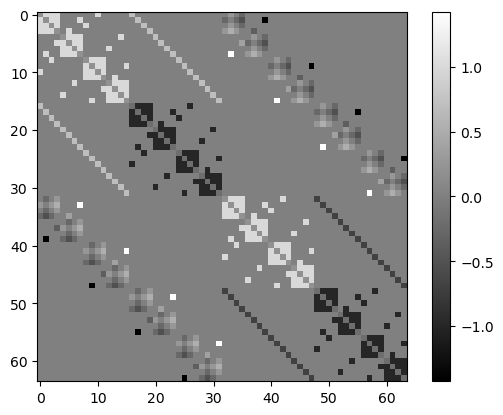

In [7]:
show_matrix(real(Hfull))